In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display

In [20]:
RESULTS_DIR = Path("results/g_scan")

In [21]:
L = 20
N = 13
chi_list = [64, 128, 256]

In [22]:
data = {}
for chi in chi_list:
    data[chi] = {}
    for path in sorted(RESULTS_DIR.glob(f"ni_L{L}_N{N}_chi{chi}_g*.npz")):
        g = float(path.stem.split("_g")[-1])
        d = np.load(path)
        tr_TB = d["tr_TB"]
        if len(tr_TB) == len(d["t_grid"]) - 1:
            tr_TB = np.concatenate([[1.0], tr_TB])
        entry = {k: d[k] for k in d.files}
        entry["tr_TB"] = tr_TB
        data[chi][g] = entry

In [35]:
data[256][1.5].keys()

dict_keys(['ni', 'tr_TB', 'E_total', 't_grid', 'L', 'N', 'Na', 't_hop', 'W', 'dt', 'T', 'chi', 'g', 'seed'])

In [49]:
data[256][2.269231]['ni'].shape

(20, 1601)

In [37]:
data[256][1.5]['tr_TB'].shape

(423,)

In [40]:
data[256][1.5]['E_total'].shape

(423,)

In [41]:
data[256][1.5]['t_grid'].shape

(1601,)

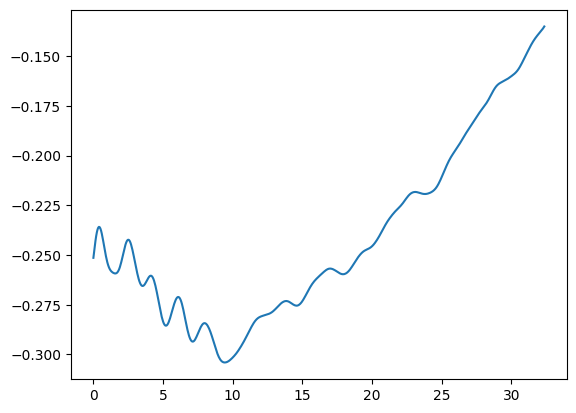

In [48]:
plt.plot(data[256][2.269231]['t_grid'][:648], data[256][2.269231]['E_total'])

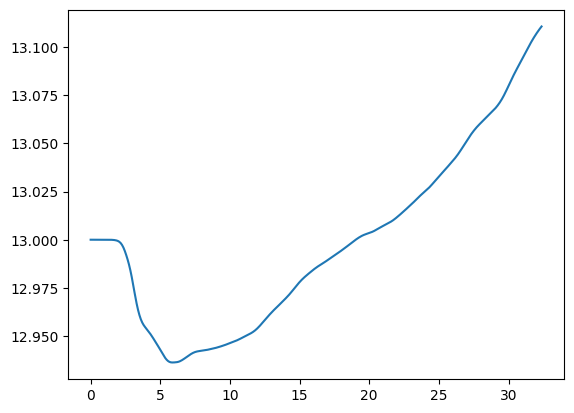

In [53]:
plt.plot(data[256][2.269231]['t_grid'][:648], np.sum(data[256][2.269231]['ni'], axis=0)[:648])

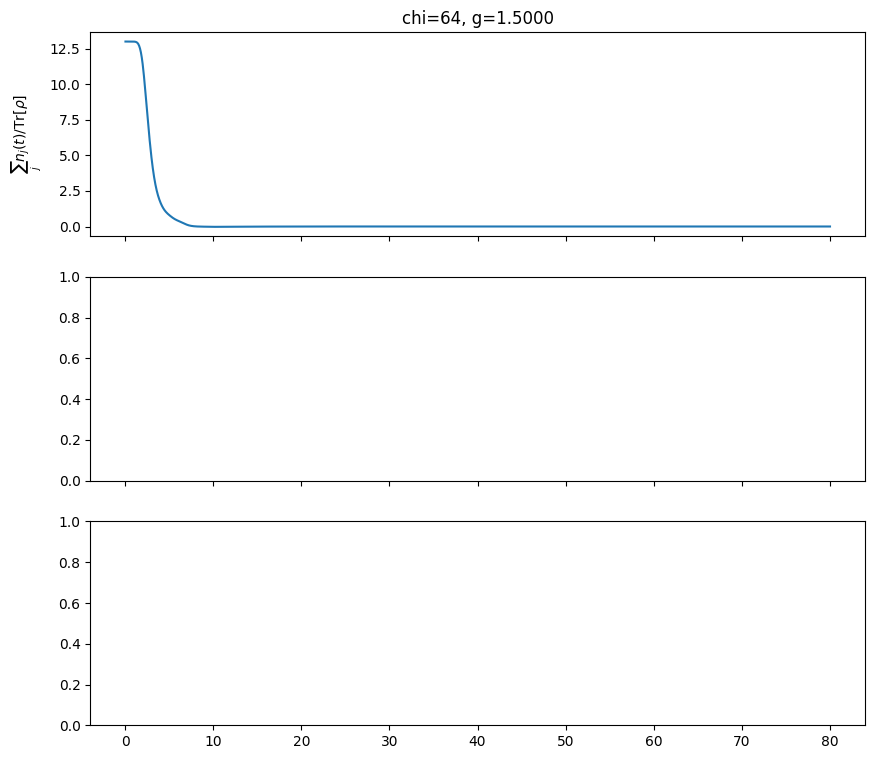

interactive(children=(Dropdown(description='chi', options=(64, 128, 256), value=64), SelectionSlider(descripti…

<function __main__.plot_chi_g(chi, g)>

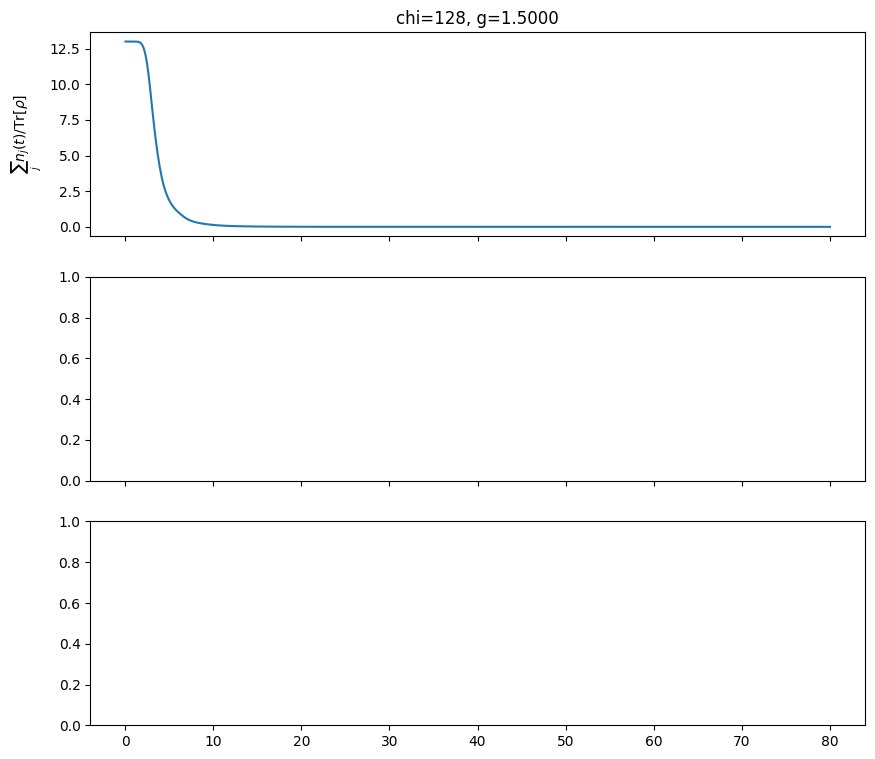

In [39]:
def plot_chi_g(chi, g):
    vals = data[chi][g]
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    axes[0].plot(vals["t_grid"], np.sum(vals["ni"], axis=0))
    axes[0].set_ylabel(r"$\sum_j n_j(t) / \mathrm{Tr}[\rho]$")
    axes[0].set_title(f"chi={chi}, g={g:.4f}")
    axes[1].plot(vals["t_grid"][:423], vals["E_total"])
    axes[1].set_ylabel(r"$E(t) / \mathrm{Tr}[\rho]$")
    axes[2].plot(vals["t_grid"], vals["tr_TB"], color="k")
    axes[2].axhline(1, color="gray", linestyle=":", linewidth=1)
    axes[2].set_yscale("log")
    axes[2].set_ylabel(r"$\mathrm{Tr}[\rho](t)$")
    axes[2].set_xlabel("time")
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_chi_g,
    chi=widgets.Dropdown(options=chi_list, description="chi"),
    g=widgets.SelectionSlider(options=sorted(data[chi_list[0]].keys()), description="g"),
)

In [32]:
def plot_chi_g(chi, g):
    vals = data[chi][g]
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    axes[0].plot(vals["t_grid"], np.sum(vals["ni"], axis=0) / vals["tr_TB"])
    axes[0].set_ylabel(r"$\sum_j n_j(t) / \mathrm{Tr}[\rho]$")
    axes[0].set_title(f"chi={chi}, g={g:.4f}")
    axes[1].plot(vals["t_grid"], vals["E_total"] / vals["tr_TB"])
    axes[1].set_ylabel(r"$E(t) / \mathrm{Tr}[\rho]$")
    axes[2].plot(vals["t_grid"], vals["tr_TB"], color="k")
    axes[2].axhline(1, color="gray", linestyle=":", linewidth=1)
    axes[2].set_yscale("log")
    axes[2].set_ylabel(r"$\mathrm{Tr}[\rho](t)$")
    axes[2].set_xlabel("time")
    plt.tight_layout()
    plt.show()

widgets.interact(
    plot_chi_g,
    chi=widgets.Dropdown(options=chi_list, description="chi"),
    g=widgets.SelectionSlider(options=sorted(data[chi_list[0]].keys()), description="g"),
)

interactive(children=(Dropdown(description='chi', options=(64, 128, 256), value=64), SelectionSlider(descripti…

<function __main__.plot_chi_g(chi, g)>

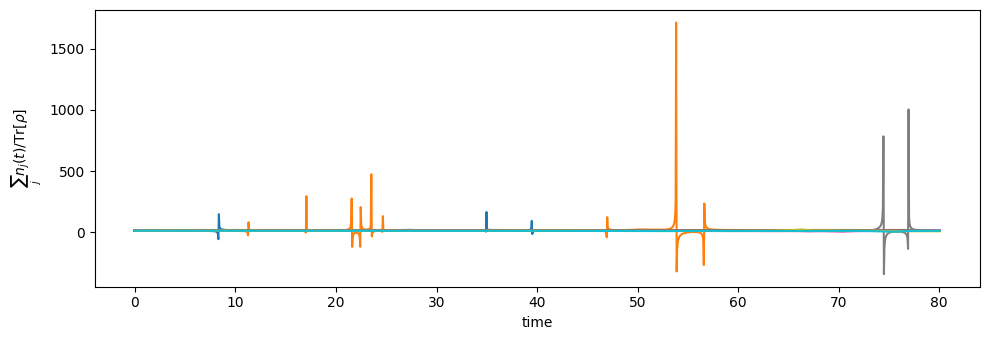

In [24]:
plt.figure(figsize=(10, 3.5))
for g, vals in data[64].items():
    plt.plot(vals["t_grid"], np.sum(vals["ni"], axis=0) / vals["tr_TB"], label=f"g={g}")
plt.ylabel(r"$\sum_j n_j(t) / \mathrm{Tr}[\rho]$")
plt.xlabel("time")
# plt.legend()

plt.tight_layout()
plt.show()

In [25]:
step = int(30 / 0.05)

In [26]:
def plot_ni_profile(chi, g):
    vals = data[chi][g]
    t_grid = vals["t_grid"]
    ni_norm = vals["ni"] / vals["tr_TB"]   # shape (L, T)
    ni_norm = ni_norm[5:15,:]
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, ni_i in enumerate(ni_norm):
        ax.plot(t_grid[step:], ni_i[step:], label=f"i={i}")
        ax.axhline(vals["N"] / vals["L"], color="gray", linestyle="--", linewidth=1)
    ax.set_ylabel(r"$\langle n_i \rangle(t)$")
    ax.set_xlabel("time")
    ax.set_title(f"chi={chi}, g={g:.4f}")
    ax.legend(loc="upper right", ncol=4, fontsize=7)
    plt.tight_layout()
    # plt.ylim(0,1)
    plt.show()

widgets.interact(
    plot_ni_profile,
    chi=widgets.Dropdown(options=chi_list, description="chi"),
    g=widgets.SelectionSlider(options=sorted(data[chi_list[0]].keys()), description="g"),
)

interactive(children=(Dropdown(description='chi', options=(64, 128, 256), value=64), SelectionSlider(descripti…

<function __main__.plot_ni_profile(chi, g)>

In [27]:
data[64][2.333333]['ni'][:,0]

KeyError: 2.333333

In [ ]:
data[128][2.333333]['ni'][:,step:].mean(axis=1)

In [ ]:
np.shape(data[64][2.333333]['ni'][:,step:])

In [ ]:
0.2*np.sqrt(13)+0.2*20/4

In [ ]:
30/0.05